# 10 — The Most Improved leap, week by week

**Questions**
1. Did past Most Improved Player (MIP) winners improve **steadily through the season**, or jump at a specific point (a hot start, after the All-Star break, after a role change)?
2. Is a single huge night (Malachi Flynn's 50 points) an **indicator or a fluke**?
3. How much does a **3-, 5- or 7-game rolling average** tell you about the rest of the season?
4. (Next) Can we pick the MIP in retrospect, and was Nickeil Alexander-Walker's 2025-26 leap a **blip**?

**Decisions**
- **Production** = Hollinger **game score** (headline: one number for a game's box-score impact), shown alongside points, minutes, shot volume (shots + turnovers), assists and rebounds.
- **Baseline** = the player's per-game averages in his **most recent previous season played**.
- **Form** = 3-, 5- and 7-game rolling averages; weekly averages for display.
- MIP prediction will be limited to players with **≥ 2 previous seasons** (predicting from year 3 on).

Data: NBA.com league-wide game logs, 2010-11 → 2025-26 (404k player-games; 2010-11 only supplies 2011-12 baselines).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.gamelogs import build_game_table
from unicorn.labels import MIP_WINNERS
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
games, base, asb = build_game_table()
games.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_games.parquet", index=False)
print(games.shape)
asb

(404431, 60)


,season,last_game_before,first_game_after,gap_days
0,2010-11,2011-02-17,2011-02-22,5
1,2011-12,2012-02-23,2012-02-28,5
2,2012-13,2013-02-14,2013-02-19,5
3,2013-14,2014-02-13,2014-02-18,5
4,2014-15,2015-02-12,2015-02-19,7
5,2015-16,2016-02-11,2016-02-18,7
6,2016-17,2017-02-16,2017-02-23,7
7,2017-18,2018-02-15,2018-02-22,7
8,2018-19,2019-02-14,2019-02-21,7
9,2019-20,2020-02-13,2020-02-20,7


## 10B — How did each Most Improved winner's season unfold?

In [2]:
mip = pd.DataFrame([{"season": s, "player_id": pid} for s, pid in MIP_WINNERS.items()])
w = games.merge(mip, on=["season", "player_id"])
asb_week = games[games["after_all_star"]].groupby("season")["week"].min()

rows = []
for (s, pid), d in w.groupby(["season", "player_id"]):
    rows.append({"season": s, "player": d["player_name"].iloc[0],
                 "baseline": d["base_game_score"].iloc[0],
                 "first_10_games": d.head(10)["game_score"].mean(),
                 "before_all_star": d.loc[~d["after_all_star"], "game_score"].mean(),
                 "after_all_star": d.loc[d["after_all_star"], "game_score"].mean(),
                 "season_avg": d["game_score"].mean(),
                 "min_baseline": d["base_min"].iloc[0], "min_first_10": d.head(10)["min"].mean(), "min_season": d["min"].mean()})
summary = pd.DataFrame(rows)
summary["leap"] = summary["season_avg"] - summary["baseline"]
summary["share_of_leap_in_first_10"] = (summary["first_10_games"] - summary["baseline"]) / summary["leap"]
summary["post_vs_pre_all_star"] = summary["after_all_star"] - summary["before_all_star"]
summary.round(2)

,season,player,baseline,first_10_games,before_all_star,after_all_star,season_avg,min_baseline,min_first_10,min_season,leap,share_of_leap_in_first_10,post_vs_pre_all_star
0,2011-12,Ryan Anderson,8.48,14.20,13.25,12.80,13.05,22.17,30.6,32.16,4.57,1.25,-0.45
1,2012-13,Paul George,9.60,9.08,13.28,12.57,13.03,29.59,36.8,37.59,3.43,-0.15,-0.70
2,2013-14,Goran Dragic,12.54,11.88,16.27,14.81,15.73,33.53,32.3,35.13,3.19,-0.21,-1.46
3,2014-15,Jimmy Butler III,10.98,18.46,17.40,16.16,17.09,38.70,39.9,38.69,6.11,1.22,-1.24
4,2015-16,CJ McCollum,4.34,12.75,13.29,13.98,13.53,15.69,34.7,34.70,9.19,0.91,0.69
5,2016-17,Giannis Antetokounmpo,14.16,19.01,20.85,19.45,20.40,35.31,34.1,35.59,6.23,0.78,-1.41
6,2017-18,Victor Oladipo,10.48,16.59,18.27,15.73,17.49,33.21,32.5,34.08,7.01,0.87,-2.55
7,2018-19,Pascal Siakam,6.65,10.52,13.58,15.15,14.01,20.65,26.9,31.86,7.36,0.53,1.57
8,2019-20,Brandon Ingram,11.77,18.64,17.93,12.72,16.67,33.87,32.4,33.95,4.89,1.40,-5.21
9,2020-21,Julius Randle,13.74,18.36,18.29,18.07,18.18,32.53,37.8,37.55,4.45,1.04,-0.22


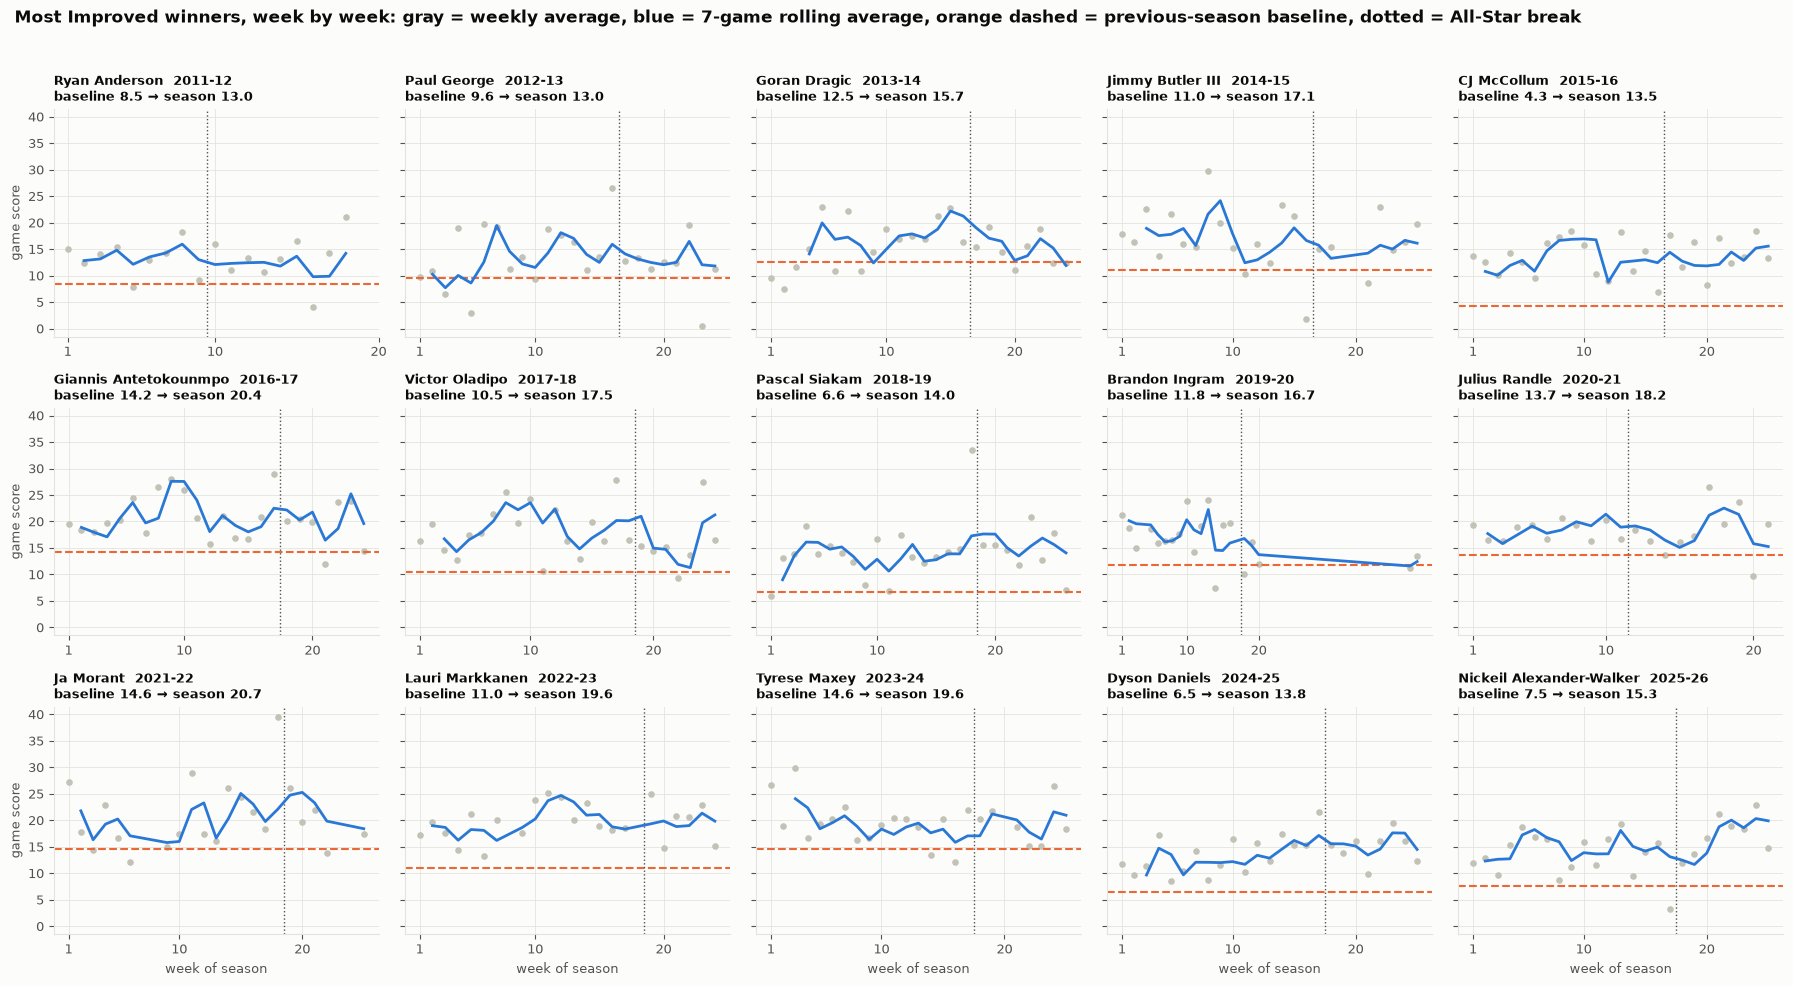

In [3]:
winners = summary.sort_values("season")
fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharey=True)
for ax, (_, r) in zip(axes.flat, winners.iterrows()):
    d = w[(w["season"] == r["season"]) & (w["player_name"] == r["player"])]
    weekly = d.groupby("week")["game_score"].mean()
    roll = d.groupby("week")["game_score_roll7"].last()
    ax.scatter(weekly.index, weekly.values, s=14, color=MUTED, zorder=2)
    ax.plot(roll.index, roll.values, color=BLUE, linewidth=2, zorder=3)
    ax.axhline(r["baseline"], color=ORANGE, linestyle="--", linewidth=1.5)
    ax.axvline(asb_week[r["season"]] - 0.5, color=INK2, linestyle=":", linewidth=1)
    ax.set_title(f"{r['player']}  {r['season']}\nbaseline {r['baseline']:.1f} → season {r['season_avg']:.1f}", loc="left", fontsize=9.5)
    ax.set_xticks([1, 10, 20])
for ax in axes[:, 0]:
    ax.set_ylabel("game score")
for ax in axes[-1]:
    ax.set_xlabel("week of season")
fig.suptitle("Most Improved winners, week by week: gray = weekly average, blue = 7-game rolling average, "
             "orange dashed = previous-season baseline, dotted = All-Star break", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96)); fig.savefig(FIG_DIR / "10_mip_week_by_week.png", dpi=150, bbox_inches="tight")

## 10C — One huge night: indicator or fluke?

An **eruption** is a game with a game score at least **20 above the player's baseline** (Flynn's 50: 42.0 vs a baseline of 3.0). Compare how the player did in the **7 games before** and the **7 games after** against his baseline.

In [4]:
g = games[games["base_game_score"].notna()].copy()
g["excess"] = g["game_score"] - g["base_game_score"]
ps = g.groupby(["player_id", "season_start"])["excess"]
g["prev7"] = ps.transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
g["next7"] = ps.transform(lambda s: s[::-1].shift(1).rolling(7, min_periods=7).mean()[::-1])
eruptions = g[g["excess"] >= 20].dropna(subset=["prev7", "next7"])
others = g.dropna(subset=["prev7", "next7"])
print(f"{len(eruptions)} eruption games (with 7 games either side) out of {len(others):,} games")
print(f"after an eruption, next 7 games vs baseline: {eruptions['next7'].mean():+.1f} game score "
      f"(the 7 before: {eruptions['prev7'].mean():+.1f}); for all games: next 7 {others['next7'].mean():+.1f}")
flynn = g[(g["player_name"] == "Malachi Flynn") & (g["pts"] >= 50)]
display(flynn[["season", "game_date", "matchup", "min", "pts", "game_score", "base_game_score", "prev7", "next7"]].round({"game_score": 1, "base_game_score": 1, "prev7": 1}))
print("Flynn's remaining games that season:")
f_season = g[(g["player_name"] == "Malachi Flynn") & (g["season"] == flynn["season"].iloc[0])]
display(f_season[f_season["game_date"] >= flynn["game_date"].iloc[0]][["game_date", "matchup", "min", "pts", "game_score"]])

1184 eruption games (with 7 games either side) out of 246,818 games
after an eruption, next 7 games vs baseline: +3.8 game score (the 7 before: +3.5); for all games: next 7 +0.4


,season,game_date,matchup,min,pts,game_score,base_game_score,prev7,next7
356021,2023-24,2024-04-03,DET @ ATL,34.0,50,42.0,3.0,4.7,NaN


Flynn's remaining games that season:


,game_date,matchup,min,pts,game_score
356021,2024-04-03,DET @ ATL,34.0,50,42.0
356022,2024-04-05,DET @ MEM,23.0,3,-1.3
356023,2024-04-06,DET @ BKN,15.0,3,-0.1
356024,2024-04-09,DET @ PHI,21.0,12,7.7
356025,2024-04-11,DET vs. CHI,15.0,12,5.9
356026,2024-04-12,DET @ DAL,16.0,10,12.1
356027,2024-04-14,DET @ SAS,20.0,4,1.6


In [5]:
# Was the eruption a sign of a real step up? Bucket by what the 7 games BEFORE looked like
eruptions = eruptions.assign(form_before=pd.cut(eruptions["prev7"], [-99, 0, 3, 99], labels=["below baseline", "slightly above (0–3)", "already well above (3+)"]))
t = eruptions.groupby("form_before", observed=True).agg(eruptions=("next7", "size"), next7_vs_baseline=("next7", "mean"),
                                                         prev7_vs_baseline=("prev7", "mean"))
t.round(2)

,eruptions,next7_vs_baseline,prev7_vs_baseline
form_before,,,
below baseline,243,1.00,-2.00
slightly above (0–3),336,2.73,1.63
already well above (3+),605,5.54,6.69


## 10D — How much do 3, 5 and 7-game averages tell you?

At a given point in the season (after game *n*), take the player's last-*k*-games average (relative to his baseline) and see how well it predicts his **rest-of-season** average (also relative to baseline). Correlation across all player-seasons with at least *n* + 15 games, ≥ 15 min per game in the baseline season.

window,last game,last 3,last 5,last 7,season to date
after game,,,,,
7,0.32,0.45,0.53,0.57,0.57
15,0.31,0.45,0.52,0.56,0.64
25,0.31,0.47,0.53,0.58,0.68
40,0.33,0.48,0.54,0.58,0.69


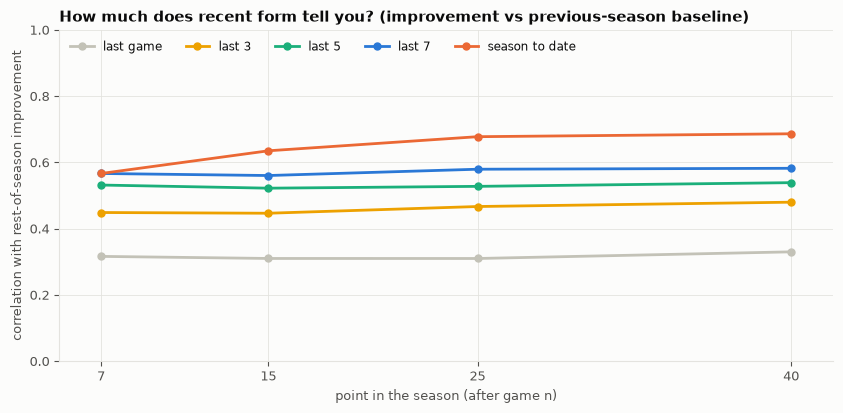

In [6]:
rows = []
gg = g[g["base_min"] >= 15].copy()
gg["games_in_season"] = gg.groupby(["player_id", "season_start"])["game_number"].transform("max")
for n in [7, 15, 25, 40]:
    cut = gg[gg["games_in_season"] >= n + 15]
    at_n = cut[cut["game_number"] == n].set_index(["player_id", "season_start"])
    rest = cut[cut["game_number"] > n].groupby(["player_id", "season_start"])["excess"].mean()
    to_date = cut[cut["game_number"] <= n].groupby(["player_id", "season_start"])["excess"].mean()
    preds = {"last game": at_n["excess"], **{f"last {k}": at_n[f"game_score_roll{k}"] - at_n["base_game_score"] for k in (3, 5, 7)},
             "season to date": to_date}
    for name, p in preds.items():
        rows.append({"after game": n, "window": name, "corr_with_rest_of_season": p.corr(rest.reindex(p.index)), "player_seasons": len(p)})
corr = pd.DataFrame(rows).pivot(index="after game", columns="window", values="corr_with_rest_of_season")
corr = corr[["last game", "last 3", "last 5", "last 7", "season to date"]]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for name, color in zip(corr.columns, [MUTED, SERIES[3], SERIES[2], SERIES[0], SERIES[1]]):
    ax.plot(corr.index, corr[name], color=color, marker="o", markersize=5, label=name)
ax.set_xticks(corr.index); ax.set_xlim(5, 42); ax.set_ylim(0, 1)
ax.set_xlabel("point in the season (after game n)"); ax.set_ylabel("correlation with rest-of-season improvement")
ax.legend(frameon=False, loc="upper left", ncol=5, fontsize=8.5)
ax.set_title("How much does recent form tell you? (improvement vs previous-season baseline)", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_rolling_window_signal.png", dpi=150, bbox_inches="tight")
corr.round(2)

## Findings so far

**How winners' seasons unfolded (10B):**
- **Most MIP leaps were there from day one.** For 11 of 15 winners, the first 10 games already showed 80%+ of the full-season jump in game score. The leap usually came with a **new role from opening night**: McCollum 15.7 → 34.7 minutes, Daniels 22.3 → 33.0, Anderson 22.2 → 30.6.
- **Three grew into it during the season:** Paul George and Dragić started at their baseline and climbed; Siakam showed half the leap early, then kept rising.
- **The All-Star break rarely mattered.** Most winners were flat or slightly *down* after it (Ingram −5.2, mostly the 2020 bubble). The exceptions rose: **Nickeil Alexander-Walker +3.7** (14.2 → 17.9), Daniels +1.9, Siakam +1.6.
- **NAW is the strongest late riser of all 15 winners.** He had only half his leap in the first 10 games, his minutes kept growing (30 → 33), and his best form came after the All-Star break (7-game average about 20 by season's end). Whether that late surge carries into 2026-27 is the "blip or real" question.

**One huge night: indicator or fluke? (10C)**
- Across 1,184 "eruption" games (game score ≥ 20 above baseline), the next 7 games averaged **+3.8 above baseline**, almost identical to the 7 games *before* (+3.5). **The eruption itself adds little; it mostly confirms form that was already there.**
- If the player was *below* his baseline before the eruption, the next 7 games averaged only +1.0. **Flynn is that case:** +4.7 in the 7 games before his 50-pointer, then game scores of −1.3, −0.1, 7.7, 5.9, 12.1 and 1.6 to finish the season. **A fluke.**

**Which window to trust (10D):**
- **A single game is a weak signal** (correlation about 0.3 with rest-of-season improvement); 3 games about 0.45, 5 about 0.53, 7 about 0.57.
- **Season-to-date wins once there are 15+ games** (0.64 → 0.69). The 7-game average is the best *short-term* gauge, but it never beats the full sample.

**Next:** (1) **blip or real**: what share of the leap winners and other big leapers keep the next season, and what predicts keeping it (age, early vs late leap, minutes change, shooting luck); (2) **pick the MIP in retrospect** for players with ≥ 2 previous seasons, including "who led at the All-Star break?".

## 10E — Picking the MIP in retrospect: our top 3 each season vs the actual winner

**Score (this section) = points-per-game change vs the player's own most recent previous season.** A player going 6 → 17 ppg (+11) outranks one going 17 → 24 (+7), because MIP is about improving *on yourself*. 10F below uses changes in **every** stat.

**Eligible** (same rule every season; the 65-game award rule is deliberately ignored):
- **≥ 2 previous NBA seasons** (year 3 onwards);
- a previous season to compare against;
- **at least half the season's games**, so a short hot streak can't win.

MIP voting happens after the season, so using the full season is fair.

In [7]:
from unicorn.gamelogs import mip_candidates

ps = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season.parquet")
cand = mip_candidates(games, ps)
cand["mip"] = [MIP_WINNERS.get(s) == p for s, p in zip(cand["season"], cand["player_id"])]
el = cand[cand["eligible"] & (cand["season_start"] >= 2011)].copy()
el["rank"] = el.groupby("season")["ppg_delta"].rank(ascending=False, method="min").astype(int)
el["rank_game_score"] = el.groupby("season")["game_score_delta"].rank(ascending=False, method="min").astype(int)

rows = []
for s, d in el.groupby("season"):
    top = d.nsmallest(3, "rank")
    win = d[d["mip"]].iloc[0]
    rows.append({"season": s, **{f"#{i + 1}": f"{r.player_name} (+{r.ppg_delta:.1f})" for i, r in enumerate(top.itertuples())},
                 "actual winner": f"{win.player_name} (+{win.ppg_delta:.1f})", "winner rank": win["rank"],
                 "winner rank (game score)": win["rank_game_score"], "eligible players": len(d)})
board = pd.DataFrame(rows).set_index("season")
print(f"winner in our top 3: {(board['winner rank'] <= 3).sum()}/{len(board)} | ranked #1: {(board['winner rank'] == 1).sum()} "
      f"| top 3 by game-score change: {(board['winner rank (game score)'] <= 3).sum()}/{len(board)}")
board

winner in our top 3: 7/15 | ranked #1: 2 | top 3 by game-score change: 7/15


,#1,#2,#3,actual winner,winner rank,winner rank (game score),eligible players
season,,,,,,,
2011-12,Jeff Teague (+7.4),Byron Mullens (+7.4),Andrew Bynum (+7.4),Ryan Anderson (+5.4),10,6,251
2012-13,James Harden (+9.1),Stephen Curry (+8.2),Omer Asik (+7.0),Paul George (+5.3),9,19,258
2013-14,Eric Bledsoe (+9.3),Gerald Green (+8.8),D.J. Augustin (+8.4),Goran Dragic (+5.6),19,30,255
2014-15,Hassan Whiteside (+10.1),Jimmy Butler III (+6.9),Wayne Ellington (+6.8),Jimmy Butler III (+6.9),2,2,273
2015-16,Paul George (+14.3),CJ McCollum (+14.0),Will Barton (+7.5),CJ McCollum (+14.0),2,2,275
2016-17,Russell Westbrook (+8.1),Tim Hardaway Jr. (+8.1),James Johnson (+7.8),Giannis Antetokounmpo (+6.0),11,2,269
2017-18,Tyreke Evans (+9.1),Jonathon Simmons (+7.7),Darius Miller (+7.4),Victor Oladipo (+7.2),4,2,254
2018-19,Kawhi Leonard (+10.4),Pascal Siakam (+9.7),Derrick Rose (+9.6),Pascal Siakam (+9.7),2,4,262
2019-20,Terry Rozier (+9.0),Dillon Brooks (+8.7),Damion Lee (+7.7),Brandon Ingram (+5.6),16,11,245


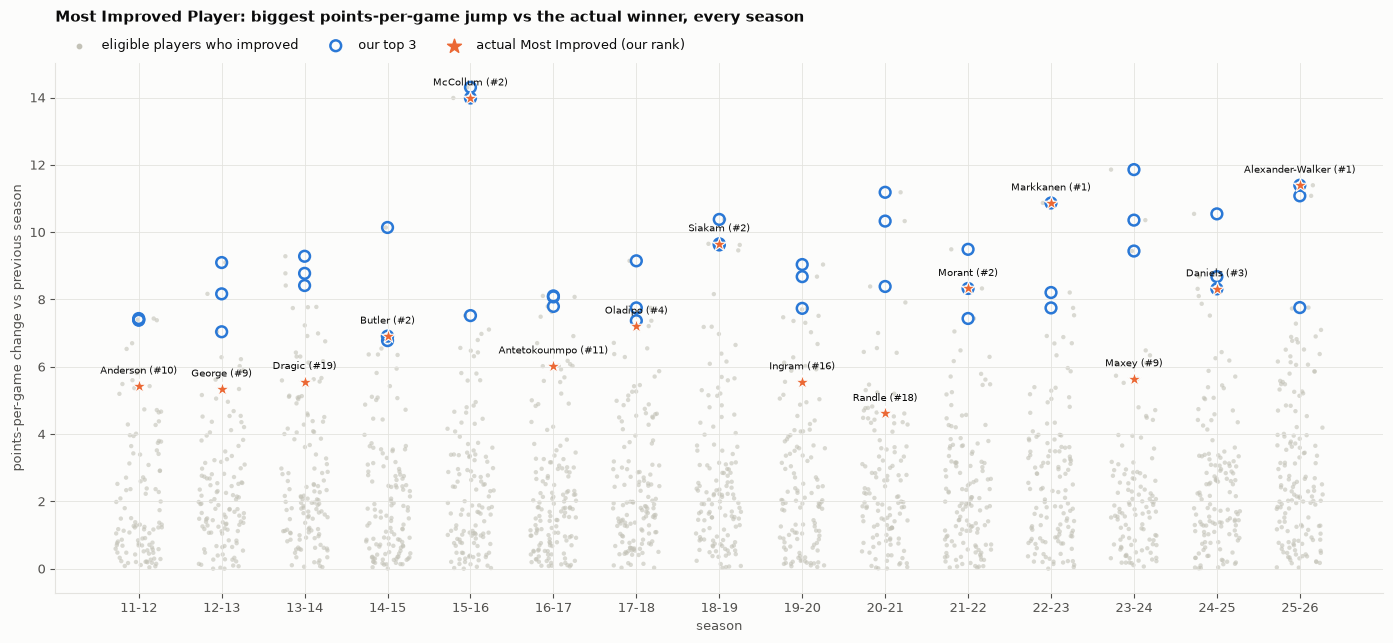

In [8]:
def short(name):
    return [p for p in name.split() if p not in {"Jr.", "Sr.", "II", "III", "IV"}][-1]

fig, ax = plt.subplots(figsize=(14, 6.5))
seasons = sorted(el["season"].unique())
rng = np.random.default_rng(0)
for i, s in enumerate(seasons):
    d = el[(el["season"] == s) & (el["ppg_delta"] > 0)]
    x = i + rng.uniform(-0.28, 0.28, len(d))
    ax.scatter(x, d["ppg_delta"], s=10, color=MUTED, alpha=0.6, edgecolor="none", zorder=1)
    top = d.nsmallest(3, "rank")
    ax.scatter(np.full(len(top), i), top["ppg_delta"], s=60, facecolor="none", edgecolor=BLUE, linewidth=1.8, zorder=3)
    w_ = d[d["mip"]]
    if len(w_):
        r = w_.iloc[0]
        ax.scatter([i], [r["ppg_delta"]], s=110, marker="*", color=ORANGE, edgecolor=SURFACE, linewidth=0.8, zorder=4)
        ax.annotate(f"{short(r['player_name'])} (#{r['rank']})", (i, r["ppg_delta"]), xytext=(0, 9),
                    textcoords="offset points", ha="center", fontsize=7.5, color=INK)
ax.set_xticks(range(len(seasons)), [s[2:] for s in seasons])
ax.set_ylabel("points-per-game change vs previous season"); ax.set_xlabel("season")
ax.scatter([], [], s=10, color=MUTED, label="eligible players who improved")
ax.scatter([], [], s=60, facecolor="none", edgecolor=BLUE, linewidth=1.8, label="our top 3")
ax.scatter([], [], s=110, marker="*", color=ORANGE, label="actual Most Improved (our rank)")
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3)
ax.set_title("Most Improved Player: biggest points-per-game jump vs the actual winner, every season", loc="left", pad=30)
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_top3_vs_winner.png", dpi=150, bbox_inches="tight")

In [9]:
print("2025-26: the top candidates")
cols = ["player_name", "team", "base_ppg", "ppg", "ppg_delta", "game_score_delta", "mpg_delta", "award_games", "rank", "mip"]
el[el["season"] == "2025-26"].nsmallest(8, "rank")[cols].round(1).reset_index(drop=True)

2025-26: the top candidates


,player_name,team,base_ppg,ppg,ppg_delta,game_score_delta,mpg_delta,award_games,rank,mip
0,Nickeil Alexander-Walker,ATL,9.4,20.8,11.4,7.8,8.1,78,1,True
1,Ryan Rollins,MIL,6.2,17.3,11.1,8.5,17.5,74,2,False
2,Lauri Markkanen,UTA,19.0,26.7,7.8,7.0,3.0,42,3,False
3,Jalen Duren,DET,11.8,19.5,7.7,5.1,2.1,67,4,False
4,Deni Avdija,POR,16.9,24.2,7.3,5.1,3.3,65,5,False
5,Bryce McGowens,NOP,1.0,8.1,7.1,6.1,18.6,27,6,False
6,Andrew Nembhard,IND,10.0,16.9,6.9,4.8,2.4,57,7,False
7,Tre Jones,CHI,7.2,14.1,6.9,5.3,7.3,65,8,False


### 10E findings (points-per-game change only)

- **The winner is in our top 3 in 7 of 15 seasons, and #1 in 2** (Markkanen 2022-23, NAW 2025-26).
- **2025-26:** NAW (+11.4), **Ryan Rollins (+11.1)**, then Jalen Duren and Deni Avdija.
- **The misses are already-good players who jumped to All-Star level:** Dragić, Randle, Ingram, Giannis, Paul George. A points-per-game change alone undersells them; 10F adds the other stats.

## 10F — A probability for every player: changes in every stat

**Inputs:** each player's change vs his previous season in points, rebounds, assists, minutes, game score, true shooting, usage and start rate (usage and start rate are missing for 2011-12 and treated as "no change").

**Model: a choice model (conditional logit).** Each season exactly one eligible player wins. The model gives every player a score, a weighted sum of his improvements, and converts scores into **win probabilities that sum to 100% within the season**. The weights are learned from the 15 past votes, so they show **what voters actually reward**.

**Honest evaluation:** every season's probabilities come from a model that never saw that season. Main version: **trained on all the other seasons**. Strict version: **trained on earlier seasons only** (from 2016-17, once 5 seasons exist). The regularization strength is also chosen without the held-out season.

In [10]:
from unicorn.mip import DELTAS, ChoiceModel, out_of_sample_probabilities, summarize

e = el.reset_index(drop=True)
results, probs = {}, {}
for name, feats in {"points-per-game change only": ["ppg_delta"], "all stat changes": DELTAS}.items():
    for scheme, label in [("loso", "trained on all other seasons"), ("walk_forward", "trained on earlier seasons only")]:
        probs[(name, scheme)] = out_of_sample_probabilities(e, feats, scheme)
        results[(name, label)] = summarize(e, probs[(name, scheme)])
pd.DataFrame(results).T.round(3)

seasons  \
points-per-game change only trained on all other seasons        15.0   
                            trained on earlier seasons only     10.0   
all stat changes            trained on all other seasons        15.0   
                            trained on earlier seasons only     10.0   

                                                             winner #1  \
points-per-game change only trained on all other seasons           2.0   
                            trained on earlier seasons only        2.0   
all stat changes            trained on all other seasons           4.0   
                            trained on earlier seasons only        4.0   

                                                             winner top 3  \
points-per-game change only trained on all other seasons              7.0   
                            trained on earlier seasons only           5.0   
all stat changes            trained on all other seasons              9.0   
                            trained on earlier seasons only           5.0   

                                                             median winner rank  \
points-per-game change only trained on all other seasons                    4.0   
                            trained on earlier seasons only                 3.5   
all stat changes            trained on all other seasons                    3.0   
                            trained on earlier seasons only                 4.0   

                                                             mean winner probability  \
points-per-game change only trained on all other seasons                       0.106   
                            trained on earlier seasons only                    0.106   
all stat changes            trained on all other seasons                       0.159   
                            trained on earlier seasons only                    0.171   

                                                             log-likelihood vs random pick  
points-per-game change only trained on all other seasons                             2.499  
                            trained on earlier seasons only                          2.563  
all stat changes            trained on all other seasons                             2.707  
                            trained on earlier seasons only                          3.070

mpg_delta          -1.02
ts_delta           -0.24
start_rate_delta    0.02
apg_delta           0.04
rpg_delta           0.10
usg_delta           0.63
ppg_delta           0.90
game_score_delta    1.68
dtype: float64

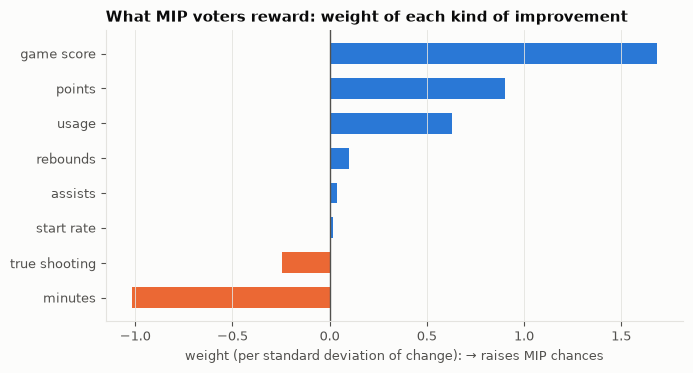

In [11]:
coef = ChoiceModel(DELTAS, l2=1.0).fit(e).coefficients().sort_values()
labels = {"ppg_delta": "points", "rpg_delta": "rebounds", "apg_delta": "assists", "mpg_delta": "minutes",
          "game_score_delta": "game score", "ts_delta": "true shooting", "usg_delta": "usage", "start_rate_delta": "start rate"}
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh([labels[c] for c in coef.index], coef.values, color=np.where(coef > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("weight (per standard deviation of change): → raises MIP chances")
ax.set_title("What MIP voters reward: weight of each kind of improvement", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "10_mip_vote_weights.png", dpi=150, bbox_inches="tight")
coef.round(2)

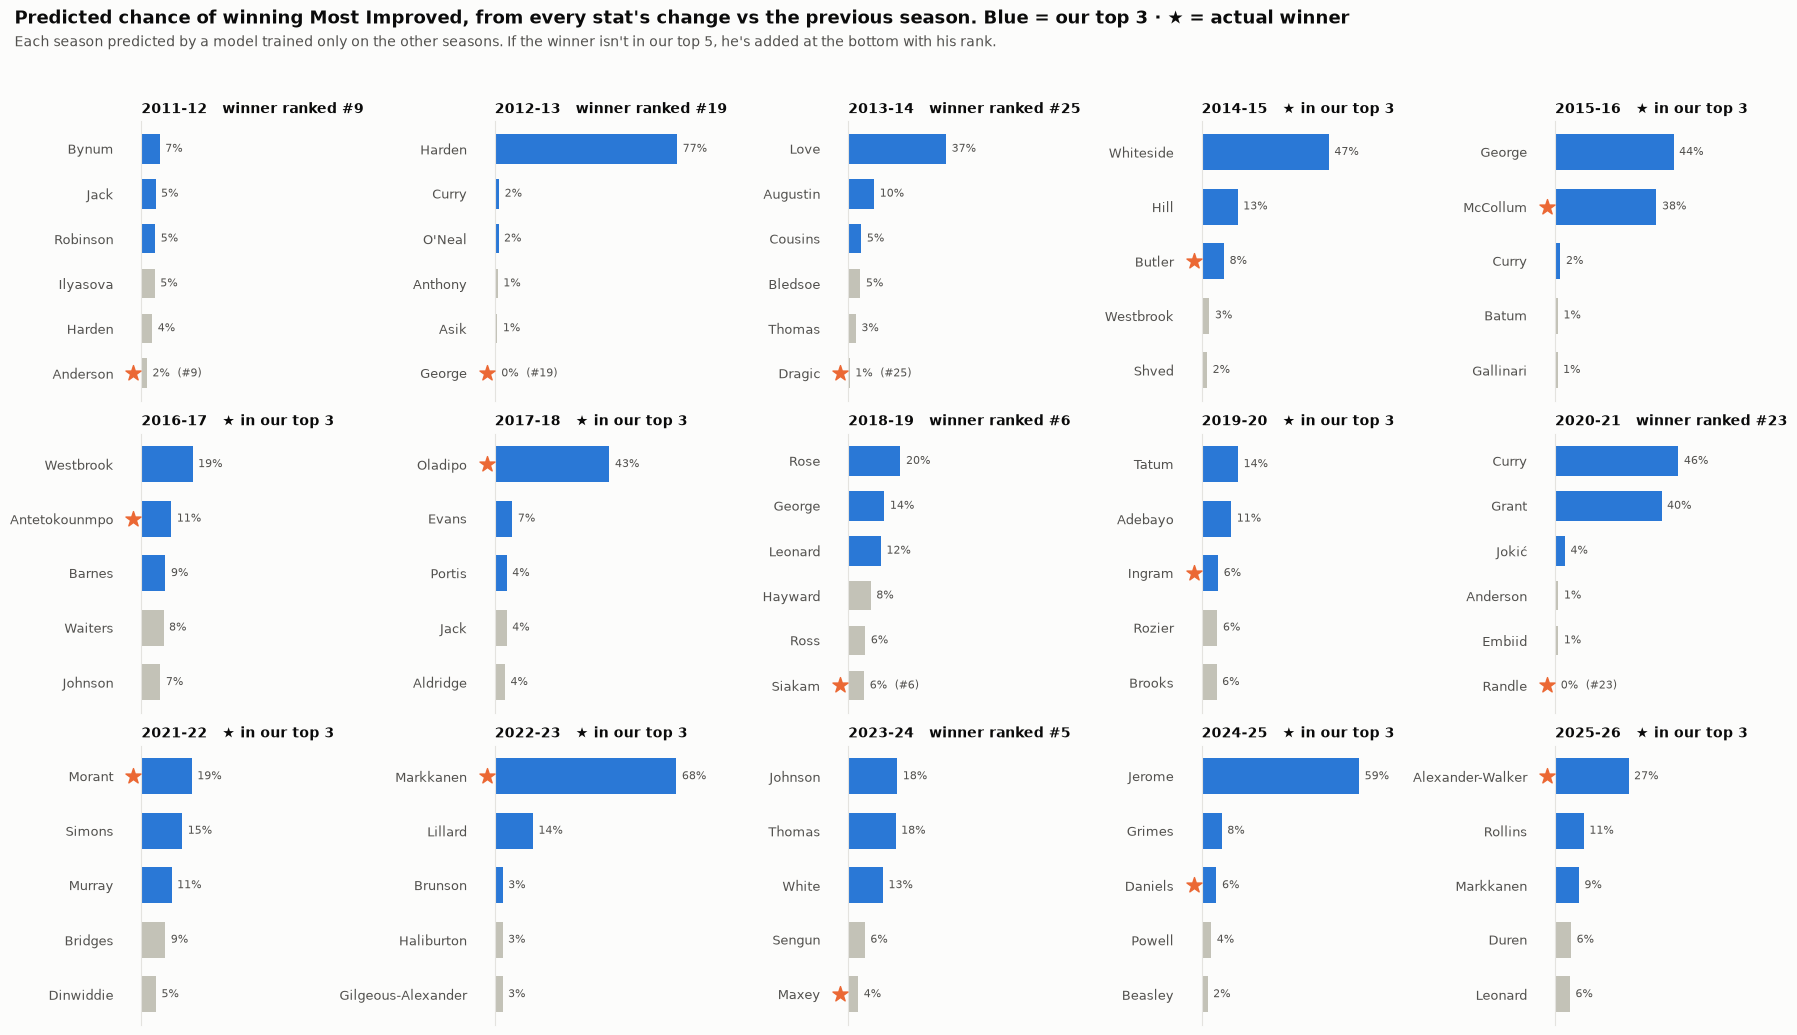

In [12]:
P = e.assign(p=probs[("all stat changes", "loso")])
P["rank"] = P.groupby("season")["p"].rank(ascending=False, method="min").astype(int)

def short(name):
    return [x for x in name.split() if x not in {"Jr.", "Sr.", "II", "III", "IV"}][-1]

seasons = sorted(P["season"].unique())
fig, axes = plt.subplots(3, 5, figsize=(18, 10.5))
for ax, s in zip(axes.flat, seasons):
    d = P[P["season"] == s].sort_values("p", ascending=False)
    show = d.head(5)
    winner = d[d["mip"]]
    if not winner.empty and winner.index[0] not in show.index:
        show = pd.concat([show, winner])
    show = show.iloc[::-1]
    y = np.arange(len(show))
    colors = [BLUE if r <= 3 else MUTED for r in show["rank"]]
    ax.barh(y, show["p"], color=colors, height=0.66)
    for yi, (_, r) in zip(y, show.iterrows()):
        ax.annotate(f"{r['p']:.0%}" + (f"  (#{r['rank']})" if r["rank"] > 5 else ""), (r["p"], yi), xytext=(4, 0),
                    textcoords="offset points", va="center", fontsize=8, color=INK2)
        if r["mip"]:
            ax.scatter([-0.035], [yi], marker="*", s=130, color=ORANGE, clip_on=False, zorder=4, transform=ax.get_yaxis_transform())
    ax.set_yticks(y, [short(n) for n in show["player_name"]], fontsize=9)
    ax.set_xlim(0, max(0.85, show["p"].max() * 1.25)); ax.set_xticks([]); ax.grid(False)
    ax.spines["bottom"].set_visible(False); ax.tick_params(axis="y", length=0, pad=20)
    hit = "★ in our top 3" if (not winner.empty and winner["rank"].iloc[0] <= 3) else f"winner ranked #{winner['rank'].iloc[0]}"
    ax.set_title(f"{s}   {hit}", loc="left", fontsize=10)
fig.suptitle("Predicted chance of winning Most Improved, from every stat's change vs the previous season. "
             "Blue = our top 3 · ★ = actual winner", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.text(0.01, 0.945, "Each season predicted by a model trained only on the other seasons. If the winner isn't in our top 5, "
         "he's added at the bottom with his rank.", ha="left", fontsize=10, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.935)); fig.subplots_adjust(wspace=0.55)
fig.savefig(FIG_DIR / "10_mip_probability_bars.png", dpi=150, bbox_inches="tight")

In [13]:
print("2025-26: top candidates by predicted chance")
cols = ["player_name", "team", "p", "rank", "ppg_delta", "game_score_delta", "mpg_delta", "usg_delta", "start_rate_delta", "mip"]
P[P["season"] == "2025-26"].nsmallest(8, "rank")[cols].round(3).reset_index(drop=True)

2025-26: top candidates by predicted chance


,player_name,team,p,rank,ppg_delta,game_score_delta,mpg_delta,usg_delta,start_rate_delta,mip
0,Nickeil Alexander-Walker,ATL,0.274,1,11.394,7.827,8.079,0.075,0.788,True
1,Ryan Rollins,MIL,0.108,2,11.079,8.481,17.505,0.057,0.566,False
2,Lauri Markkanen,UTA,0.089,3,7.759,6.991,2.998,0.038,0.000,False
3,Jalen Duren,DET,0.060,4,7.731,5.058,2.142,0.070,0.000,False
4,Kawhi Leonard,LAC,0.056,5,6.379,5.937,0.270,0.046,0.000,False
5,Andrew Nembhard,IND,0.044,6,6.901,4.839,2.364,0.070,0.000,False
6,Michael Porter Jr.,BKN,0.039,7,6.056,2.967,-1.201,0.095,0.000,False
7,Deni Avdija,POR,0.038,8,7.282,5.057,3.335,0.057,0.250,False


### 10F findings

- **Changes in every stat beat the points-per-game change alone.** Winner ranked #1 in **4** seasons (vs 2) and in our **top 3 in 9 of 15** (vs 7); median winner rank 3 (vs 4); the winner's average predicted chance is 16% (vs 11%), against roughly 0.4% for a random pick from about 250 eligible players.
- **Strict check (trained on earlier seasons only, 2016-17 → 2025-26):** winner #1 in 4 of 10 seasons and top 3 in 5. Fewer seasons to learn from, but no sign the main version relies on hindsight.
- **What voters reward** (model weights):
  - **all-round game-score jump** (strongest);
  - points;
  - usage;
  - **gaining minutes counts *against* a player, all else equal.** A jump that only comes from playing more is less impressive than producing more per minute.

  Efficiency, rebounds, assists and start rate add little once those are known.
- **2025-26:** NAW **27%** (#1, won), Ryan Rollins 11%, Lauri Markkanen 9%, Jalen Duren 6%, Kawhi Leonard 6%; Deni Avdija 4% (#8).
- **Still missed:** Paul George 2012-13 (#19), Dragić 2013-14 (#25), Randle 2020-21 (#23), Siakam (#6), Maxey (#5). These winners were judged on **becoming an All-Star-level player** more than on the size of the statistical jump, which the "level reached" idea could test.